In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

df = pd.DataFrame({
    "HP": [180,80,180,80,180],
    "Age": [3,10,12,2,10],
    "Hours": [1500,8000,9000,500,5000],
    "Price": [95000,18000,42000,28000,40000]
})

X = df[["HP","Age","Hours"]]
y = df["Price"]

**MODEL 0 — INITIAL (MEAN)**

In [ ]:
y_pred_0 = np.full(len(y), y.mean())
print("Initial prediction:", y_pred_0)
print("MSE:", mean_squared_error(y, y_pred_0))

Initial prediction: [44600. 44600. 44600. 44600. 44600.]
MSE: 710240000.0


**MODEL 1 — TREE 1**

**Residuals**

In [ ]:
residual_1 = y - y_pred_0

**Train Tree 1**

In [ ]:
tree1 = DecisionTreeRegressor(max_depth=1)
tree1.fit(X, residual_1)

DecisionTreeRegressor(max_depth=1)

**Visualize Tree 1**

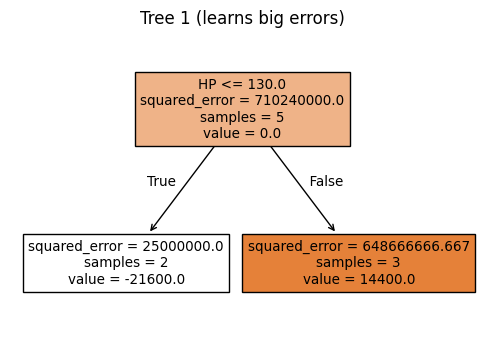

In [ ]:
plt.figure(figsize=(6,4))
plot_tree(tree1, feature_names=X.columns, filled=True)
plt.title("Tree 1 (learns big errors)")
plt.show()

**Why does Model take HP only ? why not Age or Hours .**

This is because of MSE . see Last cell

tree uses only **HP** because:

> **A decision stump (max_depth=1) can only choose ONE feature — the one that reduces error the most**


**What your tree is allowed to do**

You set:

```python
DecisionTreeRegressor(max_depth=1)
```

That means:ONLY ONE SPLIT

So the tree must choose: HP  OR  Age  OR  Hours  (only one!)
and HP gives best error reduction . what is the MSE check last cell


**When will it use other features?**

#### In later trees

Tree 2 sees **residuals**, not original target.

Now HP might not be best anymore.

 Then it may choose:

* Hours
* Age



**If you want tree to use multiple features**

#### Option 1: Increase depth

```python
DecisionTreeRegressor(max_depth=2)
```

Now tree can do:

```text
if HP < 130:
    if Hours < 4000:
        ...
```

---

#### Option 2: More trees (boosting)

Even with depth=1:

* Tree 1 → HP
* Tree 2 → Hours
* Tree 3 → Age

 Together they use all features

---

Think:

```text
Tree 1: "HP matters most"
Tree 2: "Now fix mistakes using Hours"
Tree 3: "Now fine tune using Age"
```








**Update predictions**

In [ ]:
import pandas as pd

df_out = pd.DataFrame({
    "Actual": y,
    "Tree1_Prediction": tree1.predict(X),
    "After_LR": lr * tree1.predict(X),
    "Final_Pred": y_pred_0 + lr * tree1.predict(X)
})

print(df_out)   # This is done to show all the calculation values.

   Actual  Tree1_Prediction  After_LR  Final_Pred
0   95000           14400.0    1440.0     46040.0
1   18000          -21600.0   -2160.0     42440.0
2   42000           14400.0    1440.0     46040.0
3   28000          -21600.0   -2160.0     42440.0
4   40000           14400.0    1440.0     46040.0


In [ ]:
lr = 0.1
y_pred_1 = y_pred_0 + lr * tree1.predict(X)

print("Predictions after Tree 1:", y_pred_1)
print("MSE:", mean_squared_error(y, y_pred_1)) # Printing same as above but only pred2

Predictions after Tree 1: [46040. 42440. 46040. 42440. 46040.]
MSE: 651142400.0


**MODEL 2 — TREE 2**

**New residuals**

In [ ]:
residual_2 = y - y_pred_1

**Train Tree 2**

In [ ]:
tree2 = DecisionTreeRegressor(max_depth=1)
tree2.fit(X, residual_2)

DecisionTreeRegressor(max_depth=1)

**Visualize Tree 2**

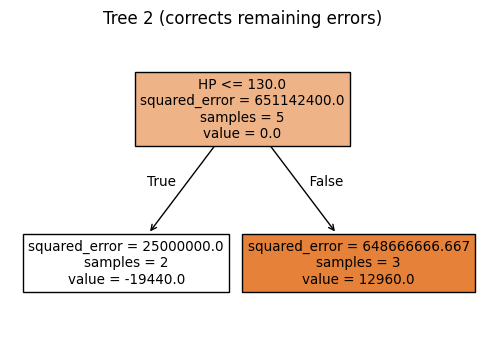

In [ ]:
plt.figure(figsize=(6,4))
plot_tree(tree2, feature_names=X.columns, filled=True)
plt.title("Tree 2 (corrects remaining errors)")
plt.show()

**Update predictions**

In [ ]:
y_pred_2 = y_pred_1 + lr * tree2.predict(X)

print("Predictions after Tree 2:", y_pred_2)
print("MSE:", mean_squared_error(y, y_pred_2))

Predictions after Tree 2: [47336. 40496. 47336. 40496. 47336.]
MSE: 603273344.0


**MODEL 3 — TREE 3**

**Residuals**

In [ ]:
residual_3 = y - y_pred_2

**Train Tree 3**

In [ ]:
tree3 = DecisionTreeRegressor(max_depth=1)
tree3.fit(X, residual_3)

DecisionTreeRegressor(max_depth=1)

**Visualize Tree 3**

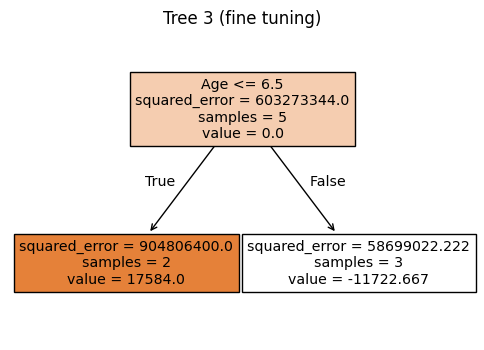

In [ ]:
plt.figure(figsize=(6,4))
plot_tree(tree3, feature_names=X.columns, filled=True)
plt.title("Tree 3 (fine tuning)")
plt.show()

**Final prediction**

In [ ]:
y_pred_3 = y_pred_2 + lr * tree3.predict(X)

print("Final predictions:", y_pred_3)
print("Final MSE:", mean_squared_error(y, y_pred_3))

Final predictions: [49094.4        39323.73333333 46163.73333333 42254.4
 46163.73333333]
Final MSE: 564108383.5733333


In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# -------------------
# Dataset
# -------------------
df = pd.DataFrame({
    "HP": [180,80,180,80,180],
    "Age": [3,10,12,2,10],
    "Hours": [1500,8000,9000,500,5000],
    "Price": [95000,18000,42000,28000,40000]
})

X = df[["HP","Age","Hours"]]
y = df["Price"].values

# -------------------
# Model 0 (Mean)
# -------------------
lr = 0.1
y_pred_0 = np.full(len(y), y.mean())

# -------------------
# Tree 1
# -------------------
tree1 = DecisionTreeRegressor(max_depth=1)
tree1.fit(X, y - y_pred_0)

# -------------------
# Tree 2
# -------------------
y_pred_1 = y_pred_0 + lr * tree1.predict(X)
tree2 = DecisionTreeRegressor(max_depth=1)
tree2.fit(X, y - y_pred_1)

# -------------------
# Tree 3
# -------------------
y_pred_2 = y_pred_1 + lr * tree2.predict(X)
tree3 = DecisionTreeRegressor(max_depth=1)
tree3.fit(X, y - y_pred_2)

# -------------------
# Final Prediction
# -------------------
final_pred = (
    y_pred_0
    + lr * tree1.predict(X)
    + lr * tree2.predict(X)
    + lr * tree3.predict(X)
)

# -------------------
# Create Output Table
# -------------------
results = pd.DataFrame({
    "Actual": y,
    "Mean (y_pred_0)": y_pred_0,
    "Tree1_Output": tree1.predict(X),
    "Tree2_Output": tree2.predict(X),
    "Tree3_Output": tree3.predict(X),
    "Final_Prediction": final_pred
})

print(results)

# -------------------
# Final MSE
# -------------------
print("\nFinal MSE:")
print(mean_squared_error(y, final_pred))

   Actual  Mean (y_pred_0)  Tree1_Output  Tree2_Output  Tree3_Output  \
0   95000          44600.0       14400.0       12960.0  17584.000000   
1   18000          44600.0      -21600.0      -19440.0 -11722.666667   
2   42000          44600.0       14400.0       12960.0 -11722.666667   
3   28000          44600.0      -21600.0      -19440.0  17584.000000   
4   40000          44600.0       14400.0       12960.0 -11722.666667   

   Final_Prediction  
0      49094.400000  
1      39323.733333  
2      46163.733333  
3      42254.400000  
4      46163.733333  

Final MSE:
564108383.5733333


**Final Prediction** =
(Mean + Tree1 correction + Tree2 correction + Tree3 correction)

**Exact Weighted MSE for Each Feature for First Model 1**

In [ ]:
import numpy as np
import pandas as pd

# Dataset
df = pd.DataFrame({
    "HP": [180,80,180,80,180],
    "Age": [3,10,12,2,10],
    "Hours": [1500,8000,9000,500,5000],
    "Price": [95000,18000,42000,28000,40000]
})

y = df["Price"].values
n = len(y)

# Function to compute best 1-split weighted MSE for a feature
def best_split_mse(feature):

    X = df[feature].values
    unique_values = np.unique(X)

    best_mse = float("inf")
    best_threshold = None

    # Try all possible midpoints between sorted unique values
    thresholds = (unique_values[:-1] + unique_values[1:]) / 2

    for t in thresholds:

        # Split
        left_mask = X <= t
        right_mask = X > t

        if sum(left_mask) == 0 or sum(right_mask) == 0:
            continue

        # Means
        left_mean = y[left_mask].mean()
        right_mean = y[right_mask].mean()

        # Weighted MSE
        left_mse = np.mean((y[left_mask] - left_mean)**2)
        right_mse = np.mean((y[right_mask] - right_mean)**2)

        weighted_mse = (sum(left_mask)/n)*left_mse + \
                       (sum(right_mask)/n)*right_mse

        if weighted_mse < best_mse:
            best_mse = weighted_mse
            best_threshold = t

    return best_mse, best_threshold


# Compute for all features
features = ["HP", "Age", "Hours"]

for f in features:
    mse, threshold = best_split_mse(f)
    print(f"{f}")
    print("Best Threshold:", threshold)
    print("Weighted MSE:", round(mse,2))
    print("-"*40)

HP
Best Threshold: 130.0
Weighted MSE: 399200000.0
----------------------------------------
Age
Best Threshold: 6.5
Weighted MSE: 519833333.33
----------------------------------------
Hours
Best Threshold: 3250.0
Weighted MSE: 519833333.33
----------------------------------------
